In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from scipy.stats import zscore

In [2]:
np.random.seed(42)

In [3]:
data_normal = np.random.normal(50, 5, 100)

In [4]:
data_outliers = np.array([10, 15, 100, 120])

In [5]:
data = np.concatenate((data_normal, data_outliers))

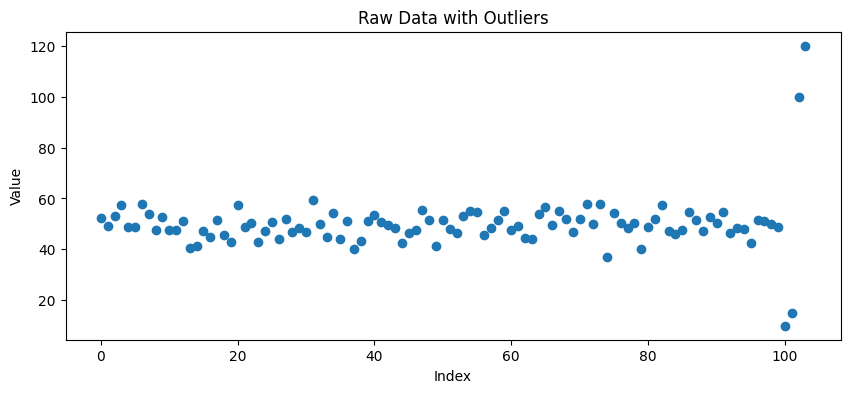

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(data, 'o')
plt.title("Raw Data with Outliers")
plt.xlabel("Index")
plt.ylabel("Value")
plt.show()

In [7]:
z_scores = zscore(data)
threshold = 3
outliers_z = np.where(np.abs(z_scores) > threshold)

In [8]:
print("Z-Score Outliers at Indices:", outliers_z[0])
print("Values:", data[outliers_z])

Z-Score Outliers at Indices: [100 101 102 103]
Values: [ 10.  15. 100. 120.]


In [9]:
X = np.random.normal(loc=0, scale=1, size=(100, 2))
X_outliers = np.random.uniform(low=-6, high=6, size=(10, 2))
X_combined = np.vstack((X, X_outliers))

In [10]:
clf = IsolationForest(contamination=0.1, random_state=42)
y_pred = clf.fit_predict(X_combined)

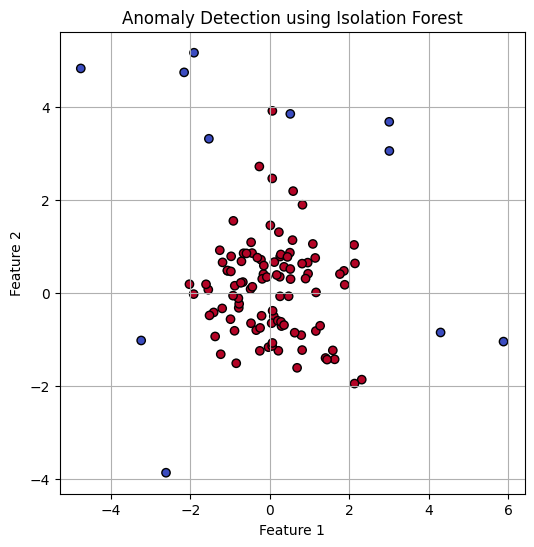

In [11]:
plt.figure(figsize=(6, 6))
plt.scatter(X_combined[:, 0], X_combined[:, 1], c=y_pred, cmap='coolwarm', edgecolor='k')
plt.title("Anomaly Detection using Isolation Forest")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()